# Lab Report 3: Binary Classification with Neural Networks
## Circles Dataset, PyTorch Artificial Neural Networks


| | |
|---|--|
|**Name** |Lijima Shrestha|
|**ROLL NO** | ACE079BCT035|
| **Lab No.** | 3 |
| **Subject** | Deep Learning / Machine Learning |
| **Topic** | Binary Classification with Artificial Neural Networks |
| **Framework** | PyTorch |
| **Dataset** | `circles_binary_classification.csv` (Circles Dataset) |



## Objective

Using the circles dataset, **build, train, evaluate, and compare multiple PyTorch Artificial Neural Networks (ANNs)** for binary classification. We will systematically increase model complexity and compare performance, culminating in a discussion of findings.



## Theoretical Background

### 1. Binary Classification
Binary classification is a supervised learning task where each input must be assigned to one of **two classes** (labeled 0 or 1). The goal is to learn a decision boundary that separates the two classes in feature space.

### 2. Artificial Neural Networks (ANNs)
An ANN is a computational model loosely inspired by biological neural networks. It consists of:
- **Input Layer**: Receives raw feature values (here: X1, X2)
- **Hidden Layers**: Learn intermediate representations through weighted connections and activation functions
- **Output Layer**: Produces a single logit (raw score) for binary classification

Each neuron computes: $z = \mathbf{w}^T \mathbf{x} + b$, and optionally applies an activation: $a = \sigma(z)$

### 3. Activation Functions
- **Linear (None)**: $f(x) = x$ — No non-linearity; unable to learn non-linear decision boundaries.
- **ReLU**: $f(x) = \max(0, x)$ — Introduces non-linearity; allows learning of complex patterns like circles.
- **Sigmoid**: $\sigma(x) = \frac{1}{1+e^{-x}}$ — Squashes output to $(0,1)$; used for final probability.

### 4. Loss Function — BCEWithLogitsLoss
$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)\right]$$
where $\hat{p}_i = \sigma(z_i)$. PyTorch's `nn.BCEWithLogitsLoss` combines sigmoid + BCE in one numerically stable operation.

### 5. Optimization — SGD
Stochastic Gradient Descent updates parameters by:
$$\theta \leftarrow \theta - \alpha \nabla_\theta \mathcal{L}$$
where $\alpha$ is the learning rate. We use full-batch gradient descent here.

### 6. Decision Boundary
The set of points where the model outputs $\hat{p} = 0.5$ (i.e., logit = 0). Visualizing this reveals how well the model has learned the structure of the data.



## Section 1: Imports & Setup

In [1]:
# ─── Standard library & data tools 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# ─── PyTorch 
import torch
import torch.nn as nn
from torch import optim

# ─── Reproducibility
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version : {torch.__version__}")
print(f"NumPy version   : {np.__version__}")
print(f"Pandas version  : {pd.__version__}")

PyTorch version : 2.10.0+cpu
,NumPy version   : 2.4.0
,Pandas version  : 2.3.3



## Section 2: Data Retrieval & Inspection

### Theory
The **circles dataset** is a synthetic 2D dataset where one class forms an inner ring and the other forms an outer ring. It is a classic benchmark for testing whether a model can learn **non-linear decision boundaries** — linear classifiers completely fail here.

We attempt to load from CSV first; if unavailable, we generate it programmatically using `sklearn.datasets.make_circles` (identical parameters).

In [3]:
# Load or Generate Dataset
import os

CSV_PATH = 'circles_binary_classification.csv'

if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
    print(f"✅ Loaded from CSV: {CSV_PATH}")
else:
    print("⚠️  CSV not found — generating dataset with sklearn.make_circles (same parameters)")
    X_raw, y_raw = make_circles(n_samples=1000, noise=0.03, random_state=42)
    df = pd.DataFrame(X_raw, columns=['X1', 'X2'])
    df['label'] = y_raw
    df.to_csv(CSV_PATH, index=False)          # save for reproducibility
    print(f"✅ Dataset saved to {CSV_PATH}")

print(f"\nDataset shape: {df.shape}")
print(f"Columns      : {list(df.columns)}")

✅ Loaded from CSV: circles_binary_classification.csv
,
,Dataset shape: (1000, 3)
,Columns      : ['X1', 'X2', 'label']


In [4]:
# First Five Rows 
print("=" * 45)
print("         HEAD  (first 5 rows)")
print("=" * 45)
df.head()

,         HEAD  (first 5 rows)
,=============================================


,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


In [5]:
# Statistical Summary
print("=" * 45)
print("      DESCRIBE  (statistical summary)")
print("=" * 45)
df.describe()

,      DESCRIBE  (statistical summary)
,=============================================


,X1,X2,label
count,1000.000000,1000.000000,1000.00000
mean,-0.000448,-0.000804,0.50000
std,0.639837,0.641156,0.50025
min,-1.059502,-1.067768,0.00000
25%,-0.619251,-0.612176,0.00000
50%,0.008762,-0.003949,0.50000
75%,0.621933,0.624822,1.00000
max,1.033712,1.036004,1.00000


In [6]:
# Class Distribution
print("Class distribution (label counts):")
print(df['label'].value_counts())
print(f"\nClass balance: {df['label'].value_counts(normalize=True).round(3).to_dict()}")
print("\nMissing values per column:")
print(df.isnull().sum())

Class distribution (label counts):
,label
,1    500
,0    500
,Name: count, dtype: int64
,
,Class balance: {1: 0.5, 0: 0.5}
,
,Missing values per column:
,X1       0
,X2       0
,label    0
,dtype: int64



## Section 3: Data Cleaning & Feature Design

### Theory
**Data cleaning** ensures the dataset is free from:
- Missing / NaN values (would break tensor operations)
- Duplicate records (would bias training)
- Incorrect dtypes

**Feature engineering** here is minimal — X1 and X2 are already the correct 2D Cartesian coordinates. The target `label` (0 or 1) is converted to `float32` because `BCEWithLogitsLoss` requires float targets.

**Dtype convention in PyTorch:**
- Features → `torch.float32` (default floating point)
- Labels → `torch.float32` (required by BCEWithLogitsLoss)

In [7]:
# Data Cleaning
print("--- Before cleaning ---")
print(f"Shape: {df.shape}")
print(f"NaN values:\n{df.isnull().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

# Drop duplicates & nulls (if any)
df = df.drop_duplicates().dropna().reset_index(drop=True)

print("\n--- After cleaning ---")
print(f"Shape: {df.shape}")
print("✅ Dataset is clean.")

--- Before cleaning ---
,Shape: (1000, 3)
,NaN values:
,X1       0
,X2       0
,label    0
,dtype: int64
,Duplicate rows: 0
,
,--- After cleaning ---
,Shape: (1000, 3)
,✅ Dataset is clean.


In [8]:
# Feature & Label Extraction 
X_np = df[['X1', 'X2']].values.astype(np.float32)   # shape: (N, 2)
y_np = df['label'].values.astype(np.float32)          # shape: (N,)

# Convert to PyTorch Tensors 
X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.float32)

print(f"X tensor shape : {X.shape}  | dtype: {X.dtype}")
print(f"y tensor shape : {y.shape}  | dtype: {y.dtype}")
print(f"\nSample X values:\n{X[:5]}")
print(f"\nSample y values: {y[:5]}")

X tensor shape : torch.Size([1000, 2])  | dtype: torch.float32
,y tensor shape : torch.Size([1000])  | dtype: torch.float32
,
,Sample X values:
,tensor([[ 0.7542,  0.2315],
,        [-0.7562,  0.1533],
,        [-0.8154,  0.1733],
,        [-0.3937,  0.6929],
,        [ 0.4422, -0.8967]])
,
,Sample y values: tensor([1., 1., 1., 1., 0.])



## Section 4: Data Visualization

### Theory
Visualization reveals the **geometric structure** of the data. For the circles dataset, we expect:
- **Class 0 (outer ring)**: points lying on a larger radius
- **Class 1 (inner circle)**: points lying on a smaller radius

This non-linear, concentric structure means **no straight-line (linear) decision boundary** can correctly separate the classes — motivating the use of deep non-linear networks.

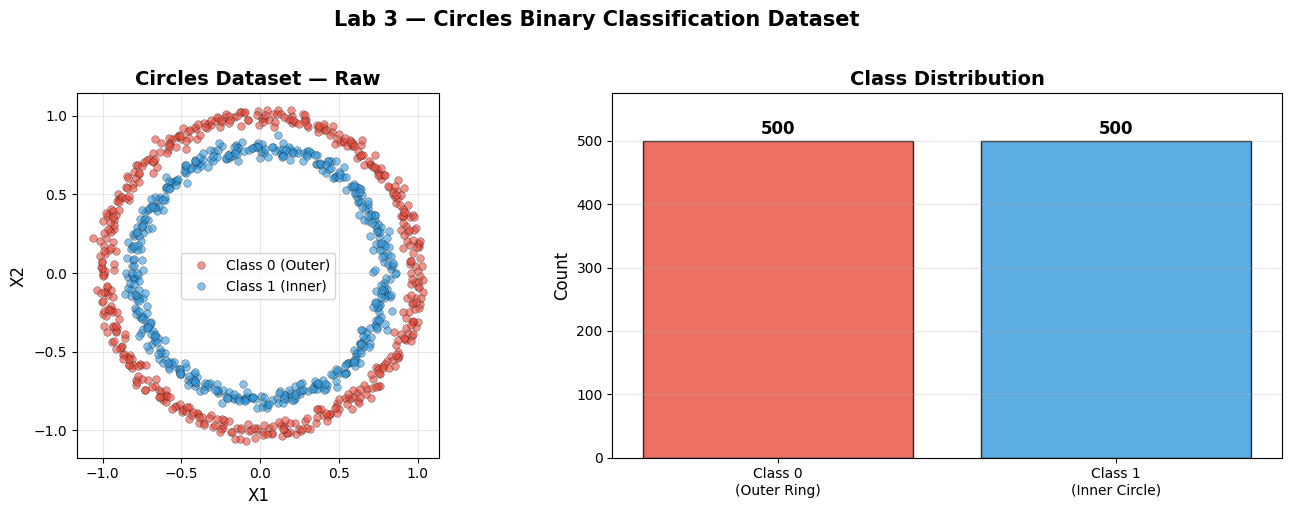

💡 Observation: Concentric ring structure — no linear boundary can separate the classes!


In [9]:
# Scatter Plot 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#E74C3C', '#3498DB']  # Red=0, Blue=1
labels_str = ['Class 0 (Outer)', 'Class 1 (Inner)']

# Left: plain scatter
ax = axes[0]
for cls, c, lbl in zip([0, 1], colors, labels_str):
    mask = y_np == cls
    ax.scatter(X_np[mask, 0], X_np[mask, 1],
               c=c, label=lbl, alpha=0.6, edgecolors='k', linewidths=0.3, s=30)
ax.set_xlabel('X1', fontsize=12)
ax.set_ylabel('X2', fontsize=12)
ax.set_title('Circles Dataset — Raw', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# Right: with class counts
ax2 = axes[1]
counts = df['label'].value_counts()
bars = ax2.bar(['Class 0\n(Outer Ring)', 'Class 1\n(Inner Circle)'],
               [counts[0], counts[1]], color=colors, edgecolor='k', alpha=0.8)
for bar, count in zip(bars, [counts[0], counts[1]]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', va='bottom', fontweight='bold', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title('Class Distribution', fontsize=14, fontweight='bold')
ax2.set_ylim(0, max(counts) * 1.15)
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('Lab 3 — Circles Binary Classification Dataset', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('dataset_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Observation: Concentric ring structure — no linear boundary can separate the classes!")


## Section 5: Train / Test Split

### Theory
We split the dataset into:
- **Training set (80%)**: Used to optimize model weights
- **Test set (20%)**: Held-out data to estimate generalization performance

`stratify=y` ensures the class ratio is preserved in both splits. `random_state=42` guarantees reproducibility.

In [10]:
# Train/Test Split 
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_np, y_np, test_size=0.2, random_state=42, stratify=y_np
)

# Convert to tensors
X_train = torch.tensor(X_train_np, dtype=torch.float32)
X_test  = torch.tensor(X_test_np,  dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32)
y_test  = torch.tensor(y_test_np,  dtype=torch.float32)

print("Split Summary")
print("═" * 38)
print(f"  Total samples     : {len(X_np)}")
print(f"  Training samples  : {len(X_train)} ({len(X_train)/len(X_np)*100:.0f}%)")
print(f"  Test samples      : {len(X_test)}  ({len(X_test)/len(X_np)*100:.0f}%)")
print("\nTensor shapes:")
print(f"  X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"  y_train: {y_train.shape}, y_test: {y_test.shape}")

print("\nClass balance in splits:")
print(f"  Train — Class 0: {(y_train_np==0).sum()}, Class 1: {(y_train_np==1).sum()}")
print(f"  Test  — Class 0: {(y_test_np==0).sum()},  Class 1: {(y_test_np==1).sum()}")

Split Summary
,══════════════════════════════════════
,  Total samples     : 1000
,  Training samples  : 800 (80%)
,  Test samples      : 200  (20%)
,
,Tensor shapes:
,  X_train: torch.Size([800, 2]), X_test: torch.Size([200, 2])
,  y_train: torch.Size([800]), y_test: torch.Size([200])
,
,Class balance in splits:
,  Train — Class 0: 400, Class 1: 400
,  Test  — Class 0: 100,  Class 1: 100



## Section 6: Device & Dtype Configuration

### Theory
PyTorch can run computations on **CPU** or **GPU (CUDA)**. Writing device-agnostic code using `torch.device('cuda' if torch.cuda.is_available() else 'cpu')` ensures the same code works in any environment without modification. All tensors and models must reside on the same device.

In [11]:
# Device-Agnostic Setup 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Using device: {device}")
if device.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Move tensors to device 
X_train = X_train.to(device)
X_test  = X_test.to(device)
y_train = y_train.to(device)
y_test  = y_test.to(device)

print(f"\n✅ All tensors moved to: {device}")
print(f"   X_train device: {X_train.device}")
print(f"   y_train device: {y_train.device}")

🖥️  Using device: cpu
,
,✅ All tensors moved to: cpu
,   X_train device: cpu
,   y_train device: cpu



## Section 7: Helper Functions

We define shared utility functions used across all model experiments:
- `accuracy_fn`: computes binary classification accuracy
- `train_and_test_loop`: unified training loop returning loss/accuracy history
- `plot_decision_boundary`: visualizes the model's learned boundary in 2D
- `plot_loss_curves`: plots training and test loss/accuracy over epochs

In [12]:
# Accuracy Function 
def accuracy_fn(y_true: torch.Tensor, y_logits: torch.Tensor) -> float:
    """Compute accuracy from raw logits and true binary labels."""
    y_pred = torch.round(torch.sigmoid(y_logits))   # convert logits → 0/1
    correct = (y_pred == y_true).sum().item()
    return correct / len(y_true) * 100


# Unified Training Loop
def train_and_test_loop(model, X_tr, y_tr, X_te, y_te,
                        loss_fn, optimizer, epochs=100, print_every=10):
    """
    Train model for `epochs` iterations.
    Returns dicts with train_loss, test_loss, train_acc, test_acc histories.
    """
    history = {'train_loss': [], 'test_loss': [],
               'train_acc':  [], 'test_acc':  []}

    for epoch in range(epochs):
        # Training phase 
        model.train()
        tr_logits = model(X_tr).squeeze()
        tr_loss   = loss_fn(tr_logits, y_tr)
        tr_acc    = accuracy_fn(y_tr, tr_logits)

        optimizer.zero_grad()
        tr_loss.backward()
        optimizer.step()

        # Evaluation phase 
        model.eval()
        with torch.inference_mode():
            te_logits = model(X_te).squeeze()
            te_loss   = loss_fn(te_logits, y_te)
            te_acc    = accuracy_fn(y_te, te_logits)

        # Store history 
        history['train_loss'].append(tr_loss.item())
        history['test_loss'].append(te_loss.item())
        history['train_acc'].append(tr_acc)
        history['test_acc'].append(te_acc)

        if (epoch + 1) % print_every == 0:
            print(f"Epoch [{epoch+1:>5}/{epochs}] | "
                  f"Train Loss: {tr_loss.item():.4f}, Train Acc: {tr_acc:.2f}% | "
                  f"Test  Loss: {te_loss.item():.4f}, Test  Acc: {te_acc:.2f}%")

    return history


# Decision Boundary Plot 
def plot_decision_boundary(model, X_data, y_data, title="", device=device):
    """Plot model's decision boundary over a 2D scatter of X_data."""
    model.eval()
    X_np_local = X_data.cpu().numpy()
    y_np_local = y_data.cpu().numpy()

    x_min, x_max = X_np_local[:, 0].min() - 0.3, X_np_local[:, 0].max() + 0.3
    y_min, y_max = X_np_local[:, 1].min() - 0.3, X_np_local[:, 1].max() + 0.3

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32).to(device)

    with torch.inference_mode():
        probs = torch.sigmoid(model(grid).squeeze()).cpu().numpy()

    zz = probs.reshape(xx.shape)

    plt.contourf(xx, yy, zz, levels=50, cmap='RdBu', alpha=0.6)
    plt.contour(xx, yy, zz, levels=[0.5], colors='k', linewidths=1.5,
                linestyles='--')   # decision boundary line

    colors = ['#E74C3C', '#3498DB']
    for cls, c in zip([0, 1], colors):
        mask = y_np_local == cls
        plt.scatter(X_np_local[mask, 0], X_np_local[mask, 1],
                    c=c, edgecolors='k', linewidths=0.4, s=20, alpha=0.8,
                    label=f'Class {cls}')

    plt.colorbar(label='Predicted Probability (Class 1)')
    plt.title(title, fontsize=12, fontweight='bold')
    plt.xlabel('X1'); plt.ylabel('X2')
    plt.legend(fontsize=9)


# Loss / Accuracy Curve Plotter
def plot_loss_curves(history, model_name):
    """Plot train/test loss and accuracy from history dict."""
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(epochs, history['train_loss'], label='Train Loss', color='#E74C3C', lw=1.5)
    axes[0].plot(epochs, history['test_loss'],  label='Test  Loss', color='#3498DB', lw=1.5,
                 linestyle='--')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{model_name} — Loss Curves', fontweight='bold')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history['train_acc'], label='Train Acc', color='#E74C3C', lw=1.5)
    axes[1].plot(epochs, history['test_acc'],  label='Test  Acc', color='#3498DB', lw=1.5,
                 linestyle='--')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title(f'{model_name} — Accuracy Curves', fontweight='bold')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ","_")}_curves.png', dpi=130, bbox_inches='tight')
    plt.show()


print("✅ All helper functions defined.")

✅ All helper functions defined.



## Section 8: Model Definitions

### Theory — Model Architecture Progression

| Model | Architecture | Activation | Purpose |
|-------|-------------|------------|--------|
| **V0** | 2 → 5 → 1 | None | Baseline: linear model, small capacity |
| **V1** | 2 → 15 → 15 → 1 | None | Wider linear model, more parameters |
| **V2** | 2 → 64 → 64 → 10 → 1 | ReLU | Non-linear model — can learn circles |
| **V3** | 2 → 128 → 128 → 64 → 1 | ReLU + Dropout | Deeper regularized model |

**Key insight**: Models V0 and V1 have no non-linear activations, so they can only learn **linear decision boundaries** — they are expected to fail on circular data. V2 and V3 use ReLU, enabling them to approximate the curved boundary.

In [13]:
#bModelV0: 2 → 5 → 1, No Activation 
class ModelV0(nn.Module):
    """Baseline linear model: 2 → 5 → 1 (no activation functions).
    
    This is a pure linear classifier — mathematically equivalent to
    logistic regression with one hidden layer. Cannot learn non-linear
    decision boundaries.
    """
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(2, 5)
        self.layer_2 = nn.Linear(5, 1)

    def forward(self, x):
        return self.layer_2(self.layer_1(x))


# ModelV1: 2 → 15 → 15 → 1, No Activation
class ModelV1(nn.Module):
    """Wider linear model: 2 → 15 → 15 → 1 (no activation functions).
    
    More parameters than V0 but still linear — composition of linear
    functions is still linear. Expected to fail on non-linear data.
    """
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(2, 15)
        self.layer_2 = nn.Linear(15, 15)
        self.layer_3 = nn.Linear(15, 1)

    def forward(self, x):
        return self.layer_3(self.layer_2(self.layer_1(x)))


#  ModelV2: 2 → 64 → 64 → 10 → 1, ReLU 
class ModelV2(nn.Module):
    """Non-linear model: 2 → 64 → 64 → 10 → 1 with ReLU activations.
    
    ReLU introduces non-linearity, enabling the model to learn the
    circular decision boundary required by this dataset.
    """
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(2, 64)
        self.layer_2 = nn.Linear(64, 64)
        self.layer_3 = nn.Linear(64, 10)
        self.layer_4 = nn.Linear(10, 1)
        self.relu    = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.layer_1(x))
        x = self.relu(self.layer_2(x))
        x = self.relu(self.layer_3(x))
        return self.layer_4(x)


#  ModelV3: Deeper Model with Dropout (Extension) 
class ModelV3(nn.Module):
    """Extended model: 2 → 128 → 128 → 64 → 1 with ReLU and Dropout.
    
    Deeper architecture with Dropout (p=0.2) for regularization.
    Tests whether extra capacity further improves performance.
    """
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)


#  Parameter Count Utility 
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


#  Architecture Summary 
models_info = [
    ('ModelV0', ModelV0(), '2→5→1',           'None'),
    ('ModelV1', ModelV1(), '2→15→15→1',       'None'),
    ('ModelV2', ModelV2(), '2→64→64→10→1',    'ReLU'),
    ('ModelV3', ModelV3(), '2→128→128→64→1',  'ReLU + Dropout'),
]

print(f"{'Model':<10} {'Architecture':<22} {'Activation':<18} {'Parameters':>10}")
print("─" * 65)
for name, m, arch, act in models_info:
    print(f"{name:<10} {arch:<22} {act:<18} {count_params(m):>10,}")

Model      Architecture           Activation         Parameters
,─────────────────────────────────────────────────────────────────
,ModelV0    2→5→1                  None                       21
,ModelV1    2→15→15→1              None                      301
,ModelV2    2→64→64→10→1           ReLU                    5,013
,ModelV3    2→128→128→64→1         ReLU + Dropout         25,217



## Section 9: ModelV0  Baseline (Linear, 2→5→1)

### Hypothesis
With no activation functions, ModelV0 is a **purely linear classifier**. It cannot separate concentrically arranged data — we expect accuracy close to **50%** (random guessing for balanced classes).

ModelV0 — Untrained Test Accuracy: 50.00%


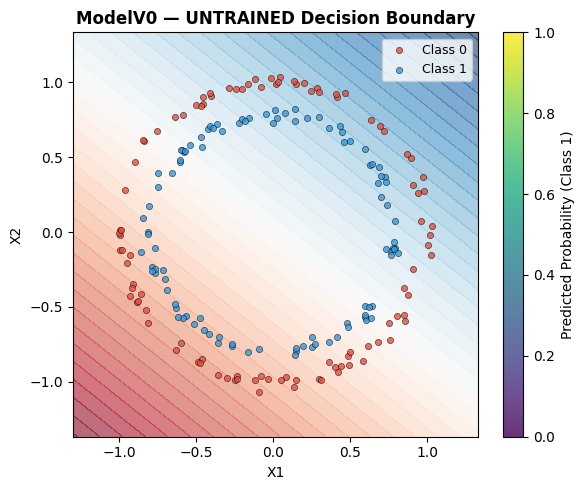

In [14]:
#  Untrained Predictions 
torch.manual_seed(42)
model_v0 = ModelV0().to(device)
loss_fn   = nn.BCEWithLogitsLoss()
optimizer_v0 = torch.optim.SGD(model_v0.parameters(), lr=0.1)

model_v0.eval()
with torch.inference_mode():
    untrained_logits = model_v0(X_test).squeeze()
    untrained_acc = accuracy_fn(y_test, untrained_logits)
print(f"ModelV0 — Untrained Test Accuracy: {untrained_acc:.2f}%")

# Plot untrained boundary
plt.figure(figsize=(6, 5))
plot_decision_boundary(model_v0, X_test, y_test,
                       title="ModelV0 — UNTRAINED Decision Boundary")
plt.tight_layout()
plt.show()

In [15]:
# Training ModelV0 (100 epochs) 
print("Training ModelV0 (2→5→1, No Activation, 100 epochs)")
print("═" * 70)
torch.manual_seed(42)
model_v0 = ModelV0().to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer_v0 = torch.optim.SGD(model_v0.parameters(), lr=0.1)

history_v0 = train_and_test_loop(
    model_v0, X_train, y_train, X_test, y_test,
    loss_fn, optimizer_v0, epochs=100, print_every=10
)

Training ModelV0 (2→5→1, No Activation, 100 epochs)
,══════════════════════════════════════════════════════════════════════
,Epoch [   10/100] | Train Loss: 0.6947, Train Acc: 50.00% | Test  Loss: 0.6940, Test  Acc: 50.00%
,Epoch [   20/100] | Train Loss: 0.6940, Train Acc: 40.38% | Test  Loss: 0.6934, Test  Acc: 43.50%
,Epoch [   30/100] | Train Loss: 0.6937, Train Acc: 46.50% | Test  Loss: 0.6932, Test  Acc: 48.00%
,Epoch [   40/100] | Train Loss: 0.6936, Train Acc: 48.12% | Test  Loss: 0.6932, Test  Acc: 49.00%
,Epoch [   50/100] | Train Loss: 0.6935, Train Acc: 49.00% | Test  Loss: 0.6932, Test  Acc: 48.00%
,Epoch [   60/100] | Train Loss: 0.6934, Train Acc: 48.62% | Test  Loss: 0.6932, Test  Acc: 51.00%
,Epoch [   70/100] | Train Loss: 0.6934, Train Acc: 49.00% | Test  Loss: 0.6932, Test  Acc: 51.00%
,Epoch [   80/100] | Train Loss: 0.6933, Train Acc: 49.25% | Test  Loss: 0.6933, Test  Acc: 49.50%
,Epoch [   90/100] | Train Loss: 0.6933, Train Acc: 48.75% | Test  Loss: 0.6933, Tes


,ModelV0 Final Results:
,  Train Accuracy : 49.38%
,  Test  Accuracy : 49.00%
,  Train Loss     : 0.6933
,  Test  Loss     : 0.6933


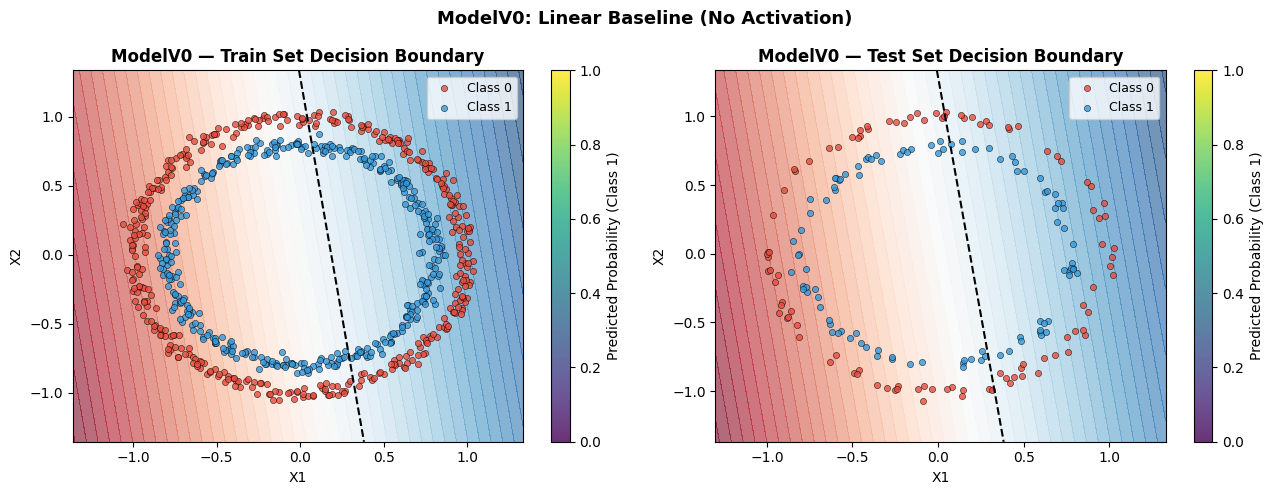

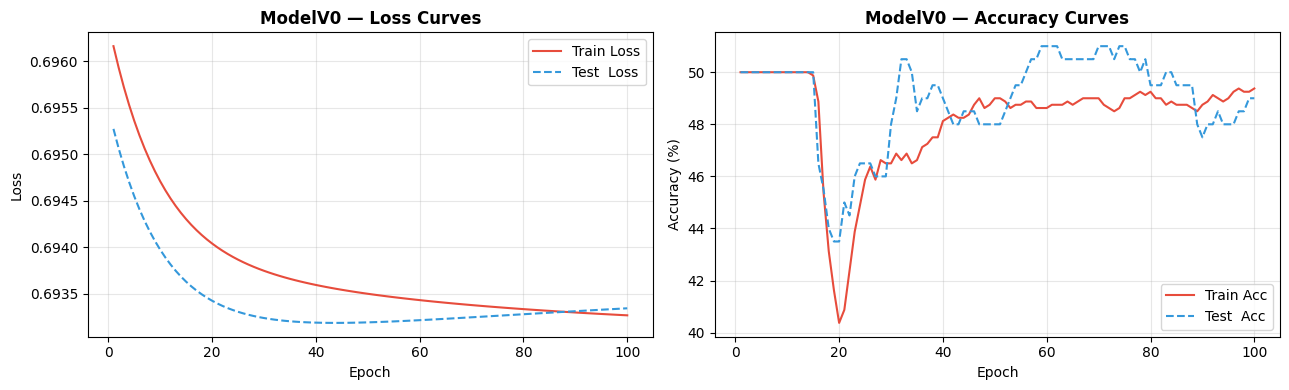

In [16]:
#  Evaluation & Visualization 
print(f"\nModelV0 Final Results:")
print(f"  Train Accuracy : {history_v0['train_acc'][-1]:.2f}%")
print(f"  Test  Accuracy : {history_v0['test_acc'][-1]:.2f}%")
print(f"  Train Loss     : {history_v0['train_loss'][-1]:.4f}")
print(f"  Test  Loss     : {history_v0['test_loss'][-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plt.sca(axes[0])
plot_decision_boundary(model_v0, X_train, y_train,
                       title="ModelV0 — Train Set Decision Boundary")
plt.sca(axes[1])
plot_decision_boundary(model_v0, X_test, y_test,
                       title="ModelV0 — Test Set Decision Boundary")
plt.suptitle('ModelV0: Linear Baseline (No Activation)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('modelV0_boundaries.png', dpi=130, bbox_inches='tight')
plt.show()

plot_loss_curves(history_v0, 'ModelV0')


## Section 10: ModelV1 — Deeper Linear (2→15→15→1)

### Hypothesis
ModelV1 has more parameters (15 hidden units × 2 layers) but **still no activation**. By the **linear composition theorem**, multiple linear layers without activations collapse to a single linear transformation. We expect minimal improvement over V0, regardless of epochs.

In [17]:
# Training ModelV1 (1000 epochs) 
print("Training ModelV1 (2→15→15→1, No Activation, 1000 epochs)")
print("═" * 70)
torch.manual_seed(42)
model_v1 = ModelV1().to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer_v1 = torch.optim.SGD(model_v1.parameters(), lr=0.1)

history_v1 = train_and_test_loop(
    model_v1, X_train, y_train, X_test, y_test,
    loss_fn, optimizer_v1, epochs=1000, print_every=100
)

Training ModelV1 (2→15→15→1, No Activation, 1000 epochs)
,══════════════════════════════════════════════════════════════════════
,Epoch [  100/1000] | Train Loss: 0.6931, Train Acc: 51.38% | Test  Loss: 0.6935, Test  Acc: 47.00%
,Epoch [  200/1000] | Train Loss: 0.6931, Train Acc: 50.62% | Test  Loss: 0.6937, Test  Acc: 48.00%
,Epoch [  300/1000] | Train Loss: 0.6931, Train Acc: 50.00% | Test  Loss: 0.6937, Test  Acc: 48.50%
,Epoch [  400/1000] | Train Loss: 0.6931, Train Acc: 50.12% | Test  Loss: 0.6937, Test  Acc: 48.50%
,Epoch [  500/1000] | Train Loss: 0.6931, Train Acc: 50.12% | Test  Loss: 0.6937, Test  Acc: 48.50%
,Epoch [  600/1000] | Train Loss: 0.6931, Train Acc: 50.12% | Test  Loss: 0.6937, Test  Acc: 48.50%
,Epoch [  700/1000] | Train Loss: 0.6931, Train Acc: 50.12% | Test  Loss: 0.6937, Test  Acc: 48.50%
,Epoch [  800/1000] | Train Loss: 0.6931, Train Acc: 50.12% | Test  Loss: 0.6937, Test  Acc: 48.50%
,Epoch [  900/1000] | Train Loss: 0.6931, Train Acc: 50.12% | Test  Los


,ModelV1 Final Results:
,  Train Accuracy : 50.12%
,  Test  Accuracy : 48.50%
,  Train Loss     : 0.6931
,  Test  Loss     : 0.6937


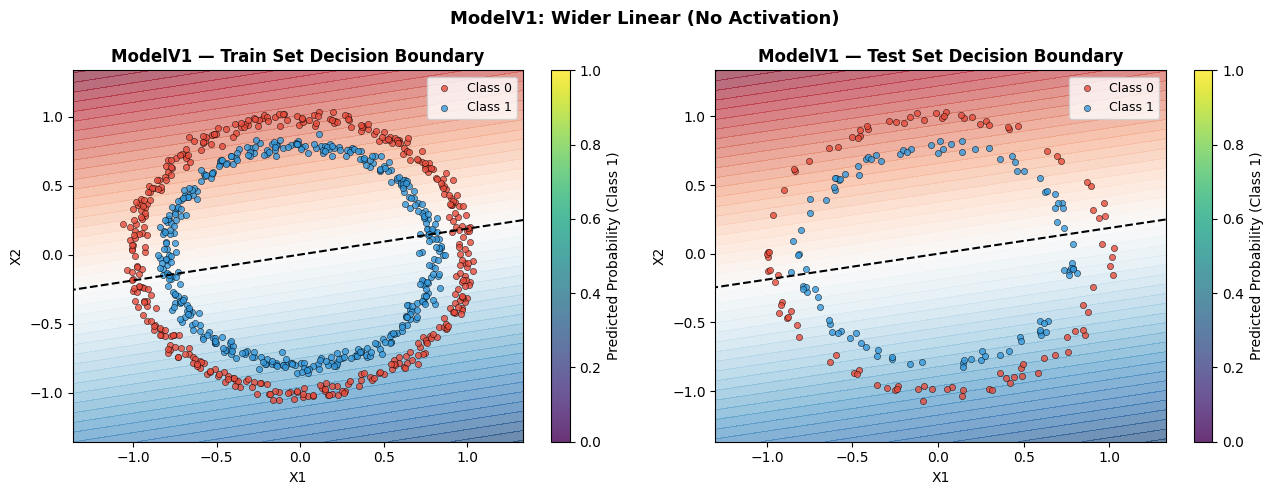

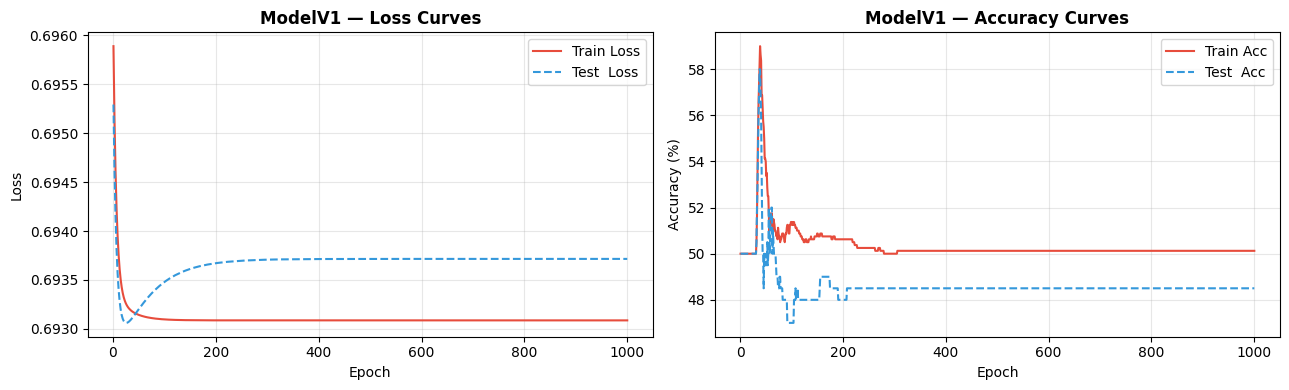

In [18]:
#  Evaluation 
print(f"\nModelV1 Final Results:")
print(f"  Train Accuracy : {history_v1['train_acc'][-1]:.2f}%")
print(f"  Test  Accuracy : {history_v1['test_acc'][-1]:.2f}%")
print(f"  Train Loss     : {history_v1['train_loss'][-1]:.4f}")
print(f"  Test  Loss     : {history_v1['test_loss'][-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plt.sca(axes[0])
plot_decision_boundary(model_v1, X_train, y_train,
                       title="ModelV1 — Train Set Decision Boundary")
plt.sca(axes[1])
plot_decision_boundary(model_v1, X_test,  y_test,
                       title="ModelV1 — Test Set Decision Boundary")
plt.suptitle('ModelV1: Wider Linear (No Activation)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('modelV1_boundaries.png', dpi=130, bbox_inches='tight')
plt.show()

plot_loss_curves(history_v1, 'ModelV1')


## Section 11: ModelV2 — Non-Linear with ReLU (2→64→64→10→1)

### Theory — Why ReLU Works Here
The **Rectified Linear Unit** $f(x) = \max(0, x)$ is a non-linear activation. By the **Universal Approximation Theorem**, a sufficiently wide network with non-linear activations can approximate *any* continuous function — including the circular decision boundary of this dataset.

With 64 hidden units per layer and ReLU, ModelV2 has both the **depth** and **non-linearity** to solve the circles problem.

In [19]:
#  Training ModelV2 (1000 epochs) 
print("Training ModelV2 (2→64→64→10→1, ReLU, 1000 epochs)")
print("═" * 70)
torch.manual_seed(42)
model_v2 = ModelV2().to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer_v2 = torch.optim.SGD(model_v2.parameters(), lr=0.1)

history_v2 = train_and_test_loop(
    model_v2, X_train, y_train, X_test, y_test,
    loss_fn, optimizer_v2, epochs=1000, print_every=100
)

Training ModelV2 (2→64→64→10→1, ReLU, 1000 epochs)
,══════════════════════════════════════════════════════════════════════
,Epoch [  100/1000] | Train Loss: 0.6889, Train Acc: 70.75% | Test  Loss: 0.6886, Test  Acc: 74.00%
,Epoch [  200/1000] | Train Loss: 0.6820, Train Acc: 84.62% | Test  Loss: 0.6816, Test  Acc: 88.00%
,Epoch [  300/1000] | Train Loss: 0.6647, Train Acc: 92.62% | Test  Loss: 0.6645, Test  Acc: 93.50%
,Epoch [  400/1000] | Train Loss: 0.5969, Train Acc: 98.88% | Test  Loss: 0.5954, Test  Acc: 98.50%
,Epoch [  500/1000] | Train Loss: 0.5156, Train Acc: 58.38% | Test  Loss: 0.4960, Test  Acc: 57.00%
,Epoch [  600/1000] | Train Loss: 0.3766, Train Acc: 77.50% | Test  Loss: 0.3681, Test  Acc: 77.50%
,Epoch [  700/1000] | Train Loss: 0.0773, Train Acc: 100.00% | Test  Loss: 0.0671, Test  Acc: 100.00%
,Epoch [  800/1000] | Train Loss: 0.0296, Train Acc: 100.00% | Test  Loss: 0.0240, Test  Acc: 100.00%
,Epoch [  900/1000] | Train Loss: 0.0169, Train Acc: 100.00% | Test  Loss


,ModelV2 Final Results:
,  Train Accuracy : 100.00%
,  Test  Accuracy : 100.00%
,  Train Loss     : 0.0114
,  Test  Loss     : 0.0099


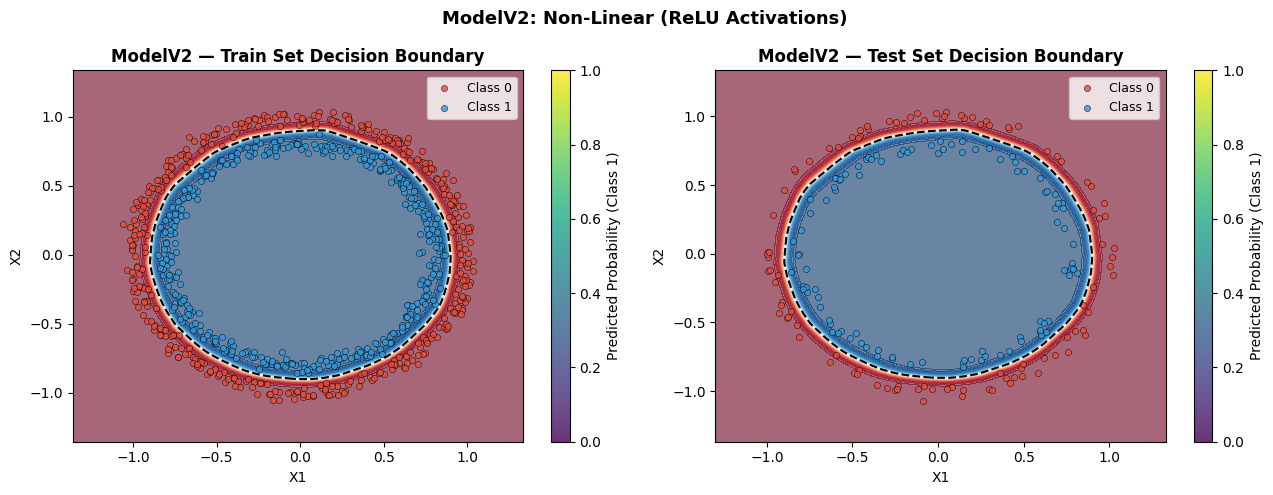

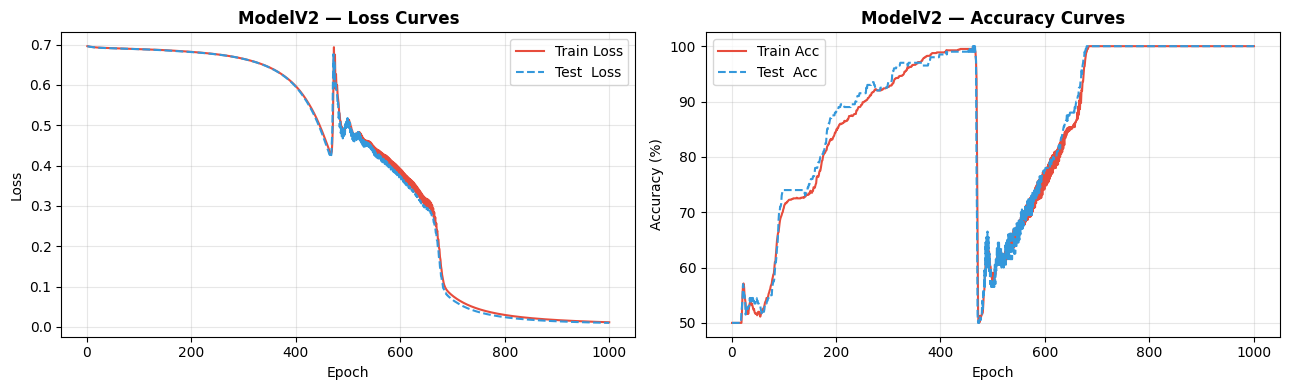

In [20]:
# Evaluation 
print(f"\nModelV2 Final Results:")
print(f"  Train Accuracy : {history_v2['train_acc'][-1]:.2f}%")
print(f"  Test  Accuracy : {history_v2['test_acc'][-1]:.2f}%")
print(f"  Train Loss     : {history_v2['train_loss'][-1]:.4f}")
print(f"  Test  Loss     : {history_v2['test_loss'][-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plt.sca(axes[0])
plot_decision_boundary(model_v2, X_train, y_train,
                       title="ModelV2 — Train Set Decision Boundary")
plt.sca(axes[1])
plot_decision_boundary(model_v2, X_test,  y_test,
                       title="ModelV2 — Test Set Decision Boundary")
plt.suptitle('ModelV2: Non-Linear (ReLU Activations)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('modelV2_boundaries.png', dpi=130, bbox_inches='tight')
plt.show()

plot_loss_curves(history_v2, 'ModelV2')


## Section 12: ModelV3 — Extension (Deeper + Dropout)

### Theory — Dropout Regularization
**Dropout** (Srivastava et al., 2014) randomly zeros a fraction `p` of neurons during each forward pass in training. This prevents co-adaptation of neurons and acts as a regularizer, reducing overfitting. At inference time, dropout is disabled and all neurons are active (scaled appropriately).

ModelV3 tests whether **deeper architecture + regularization** provides further improvement.

In [21]:
#  Training ModelV3 (1000 epochs) 
print("Training ModelV3 (2→128→128→64→1, ReLU + Dropout, 1000 epochs)")
print("═" * 70)
torch.manual_seed(42)
model_v3 = ModelV3().to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer_v3 = torch.optim.SGD(model_v3.parameters(), lr=0.1)

history_v3 = train_and_test_loop(
    model_v3, X_train, y_train, X_test, y_test,
    loss_fn, optimizer_v3, epochs=1000, print_every=100
)

Training ModelV3 (2→128→128→64→1, ReLU + Dropout, 1000 epochs)
,══════════════════════════════════════════════════════════════════════
,Epoch [  100/1000] | Train Loss: 0.6885, Train Acc: 59.50% | Test  Loss: 0.6875, Test  Acc: 58.50%
,Epoch [  200/1000] | Train Loss: 0.6817, Train Acc: 61.88% | Test  Loss: 0.6802, Test  Acc: 91.50%
,Epoch [  300/1000] | Train Loss: 0.6611, Train Acc: 71.25% | Test  Loss: 0.6609, Test  Acc: 98.50%
,Epoch [  400/1000] | Train Loss: 0.6000, Train Acc: 78.12% | Test  Loss: 0.5946, Test  Acc: 99.50%
,Epoch [  500/1000] | Train Loss: 0.4542, Train Acc: 83.75% | Test  Loss: 0.3843, Test  Acc: 100.00%
,Epoch [  600/1000] | Train Loss: 0.3670, Train Acc: 82.62% | Test  Loss: 0.3499, Test  Acc: 85.50%
,Epoch [  700/1000] | Train Loss: 0.2725, Train Acc: 89.12% | Test  Loss: 0.2193, Test  Acc: 95.00%
,Epoch [  800/1000] | Train Loss: 0.2265, Train Acc: 90.75% | Test  Loss: 0.1270, Test  Acc: 98.50%
,Epoch [  900/1000] | Train Loss: 0.1048, Train Acc: 97.00% | Te


,ModelV3 Final Results:
,  Train Accuracy : 98.00%
,  Test  Accuracy : 100.00%
,  Train Loss     : 0.0789
,  Test  Loss     : 0.0243


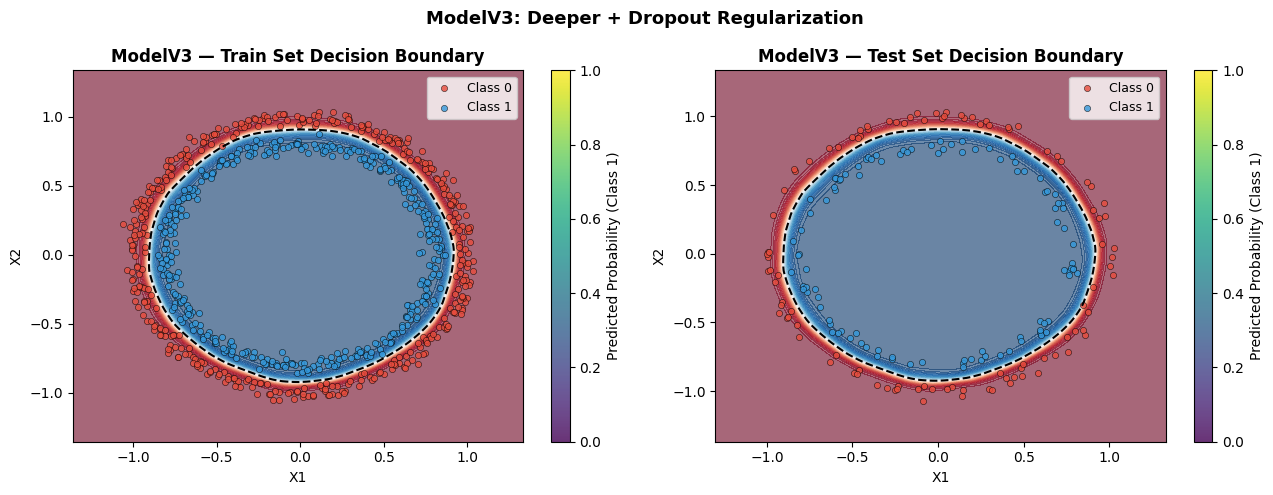

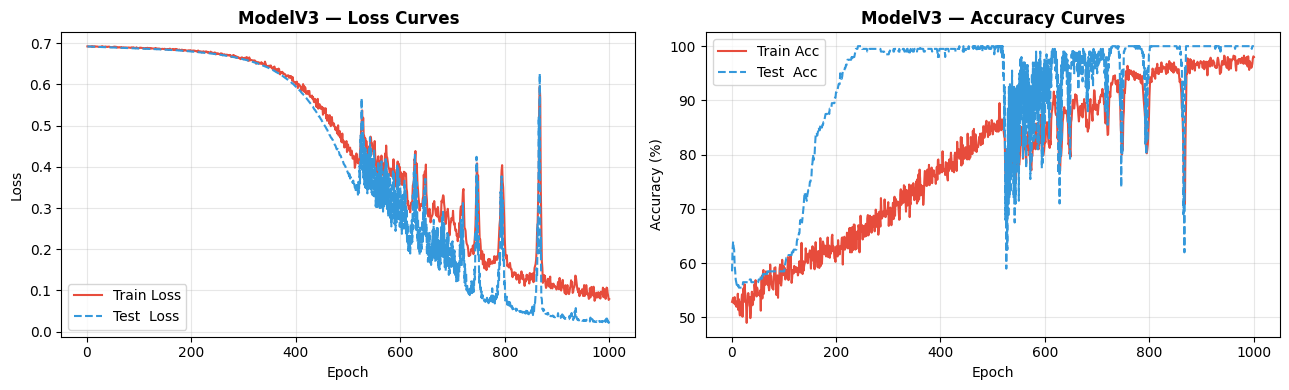

In [22]:
#  Evaluation 
print(f"\nModelV3 Final Results:")
print(f"  Train Accuracy : {history_v3['train_acc'][-1]:.2f}%")
print(f"  Test  Accuracy : {history_v3['test_acc'][-1]:.2f}%")
print(f"  Train Loss     : {history_v3['train_loss'][-1]:.4f}")
print(f"  Test  Loss     : {history_v3['test_loss'][-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plt.sca(axes[0])
plot_decision_boundary(model_v3, X_train, y_train,
                       title="ModelV3 — Train Set Decision Boundary")
plt.sca(axes[1])
plot_decision_boundary(model_v3, X_test,  y_test,
                       title="ModelV3 — Test Set Decision Boundary")
plt.suptitle('ModelV3: Deeper + Dropout Regularization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('modelV3_boundaries.png', dpi=130, bbox_inches='tight')
plt.show()

plot_loss_curves(history_v3, 'ModelV3')


## Section 13: Extra Credit — SGD vs Adam Optimizer Comparison

### Theory — Adam Optimizer
**Adam** (Adaptive Moment Estimation, Kingma & Ba, 2014) combines:
- **Momentum**: accumulates a velocity vector to smooth parameter updates
- **RMSProp**: adapts per-parameter learning rates based on recent gradient magnitudes

Update rule: $\theta_t = \theta_{t-1} - \frac{\alpha \hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$

Adam typically **converges faster** than SGD, especially in early training, but may generalize slightly worse in some cases.

We compare SGD vs Adam on **ModelV2** (same architecture, 1000 epochs).

In [23]:
#  SGD Version 
print("--- Training ModelV2 with SGD (lr=0.1) ---")
torch.manual_seed(42)
model_sgd = ModelV2().to(device)
optimizer_sgd = torch.optim.SGD(model_sgd.parameters(), lr=0.1)
loss_fn = nn.BCEWithLogitsLoss()

hist_sgd = train_and_test_loop(
    model_sgd, X_train, y_train, X_test, y_test,
    loss_fn, optimizer_sgd, epochs=1000, print_every=200
)

print(f"\n[SGD]  Final Train Acc: {hist_sgd['train_acc'][-1]:.2f}% | Test Acc: {hist_sgd['test_acc'][-1]:.2f}%")

--- Training ModelV2 with SGD (lr=0.1) ---
,Epoch [  200/1000] | Train Loss: 0.6820, Train Acc: 84.62% | Test  Loss: 0.6816, Test  Acc: 88.00%
,Epoch [  400/1000] | Train Loss: 0.5969, Train Acc: 98.88% | Test  Loss: 0.5954, Test  Acc: 98.50%
,Epoch [  600/1000] | Train Loss: 0.3766, Train Acc: 77.50% | Test  Loss: 0.3681, Test  Acc: 77.50%
,Epoch [  800/1000] | Train Loss: 0.0296, Train Acc: 100.00% | Test  Loss: 0.0240, Test  Acc: 100.00%
,Epoch [ 1000/1000] | Train Loss: 0.0114, Train Acc: 100.00% | Test  Loss: 0.0099, Test  Acc: 100.00%
,
,[SGD]  Final Train Acc: 100.00% | Test Acc: 100.00%


In [24]:
#  Adam Version 
print("--- Training ModelV2 with Adam (lr=0.001) ---")
torch.manual_seed(42)
model_adam = ModelV2().to(device)
optimizer_adam = torch.optim.Adam(model_adam.parameters(), lr=0.001)

hist_adam = train_and_test_loop(
    model_adam, X_train, y_train, X_test, y_test,
    loss_fn, optimizer_adam, epochs=1000, print_every=200
)

print(f"\n[Adam] Final Train Acc: {hist_adam['train_acc'][-1]:.2f}% | Test Acc: {hist_adam['test_acc'][-1]:.2f}%")

--- Training ModelV2 with Adam (lr=0.001) ---
,Epoch [  200/1000] | Train Loss: 0.0186, Train Acc: 100.00% | Test  Loss: 0.0168, Test  Acc: 100.00%
,Epoch [  400/1000] | Train Loss: 0.0020, Train Acc: 100.00% | Test  Loss: 0.0039, Test  Acc: 100.00%
,Epoch [  600/1000] | Train Loss: 0.0006, Train Acc: 100.00% | Test  Loss: 0.0030, Test  Acc: 100.00%
,Epoch [  800/1000] | Train Loss: 0.0003, Train Acc: 100.00% | Test  Loss: 0.0028, Test  Acc: 100.00%
,Epoch [ 1000/1000] | Train Loss: 0.0002, Train Acc: 100.00% | Test  Loss: 0.0027, Test  Acc: 100.00%
,
,[Adam] Final Train Acc: 100.00% | Test Acc: 100.00%


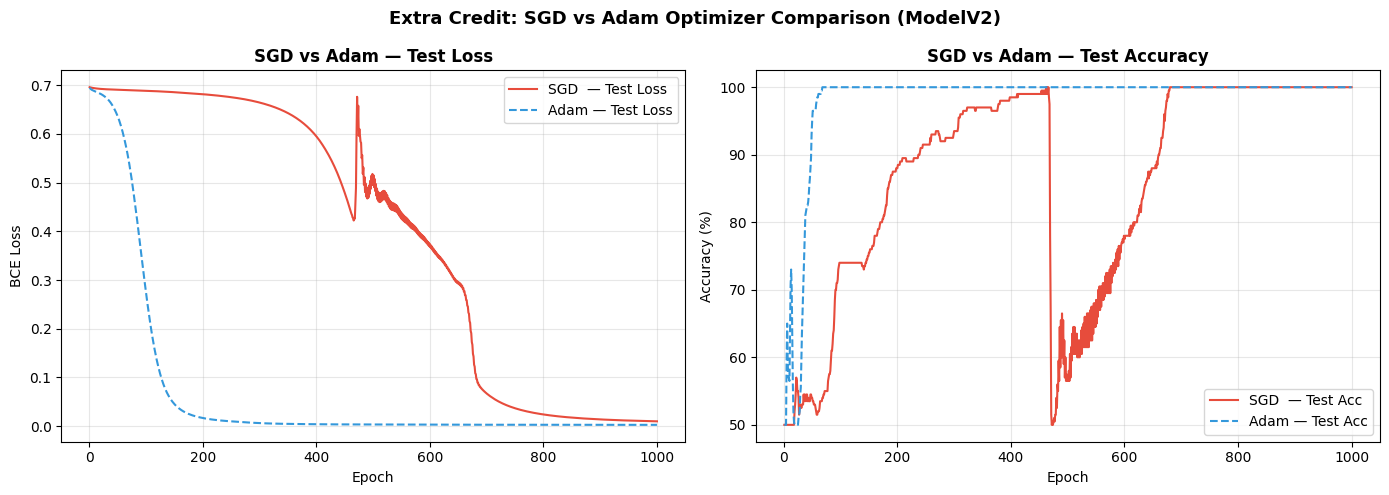


,--- Final Comparison Summary ---
,Optimizer     Train Acc     Test Acc   Train Loss    Test Loss
,──────────────────────────────────────────────────────────
,SGD             100.00%      100.00%       0.0114       0.0099
,Adam            100.00%      100.00%       0.0002       0.0027


In [25]:
#  Comparison Plot 
epochs_range = range(1, 1001)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss comparison
axes[0].plot(epochs_range, hist_sgd['test_loss'],  label='SGD  — Test Loss',  color='#E74C3C', lw=1.5)
axes[0].plot(epochs_range, hist_adam['test_loss'], label='Adam — Test Loss',  color='#3498DB', lw=1.5, linestyle='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].set_title('SGD vs Adam — Test Loss', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy comparison
axes[1].plot(epochs_range, hist_sgd['test_acc'],  label='SGD  — Test Acc',  color='#E74C3C', lw=1.5)
axes[1].plot(epochs_range, hist_adam['test_acc'], label='Adam — Test Acc',  color='#3498DB', lw=1.5, linestyle='--')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('SGD vs Adam — Test Accuracy', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Extra Credit: SGD vs Adam Optimizer Comparison (ModelV2)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sgd_vs_adam.png', dpi=130, bbox_inches='tight')
plt.show()

print("\n--- Final Comparison Summary ---")
print(f"{'Optimizer':<10} {'Train Acc':>12} {'Test Acc':>12} {'Train Loss':>12} {'Test Loss':>12}")
print("─" * 58)
print(f"{'SGD':<10} {hist_sgd['train_acc'][-1]:>11.2f}% {hist_sgd['test_acc'][-1]:>11.2f}% {hist_sgd['train_loss'][-1]:>12.4f} {hist_sgd['test_loss'][-1]:>12.4f}")
print(f"{'Adam':<10} {hist_adam['train_acc'][-1]:>11.2f}% {hist_adam['test_acc'][-1]:>11.2f}% {hist_adam['train_loss'][-1]:>12.4f} {hist_adam['test_loss'][-1]:>12.4f}")


## Section 14: Comprehensive Model Comparison

We summarize all models' final performance side-by-side and visualize their decision boundaries together.

In [27]:
#  Results Table 
results = {
    'Model':        ['V0 (Linear)',   'V1 (Linear)',   'V2 (ReLU)',    'V3 (ReLU+Drop)', 'V2+Adam'],
    'Architecture': ['2→5→1',        '2→15→15→1',     '2→64→64→10→1','2→128→128→64→1', '2→64→64→10→1'],
    'Activation':   ['None',         'None',           'ReLU',         'ReLU+Dropout',   'ReLU'],
    'Optimizer':    ['SGD',          'SGD',            'SGD',          'SGD',            'Adam'],
    'Epochs':       [100,            1000,             1000,           1000,             1000],
    'Train Acc (%)': [
        round(history_v0['train_acc'][-1], 2),
        round(history_v1['train_acc'][-1], 2),
        round(history_v2['train_acc'][-1], 2),
        round(history_v3['train_acc'][-1], 2),
        round(hist_adam['train_acc'][-1],  2),
    ],
    'Test Acc (%)': [
        round(history_v0['test_acc'][-1], 2),
        round(history_v1['test_acc'][-1], 2),
        round(history_v2['test_acc'][-1], 2),
        round(history_v3['test_acc'][-1], 2),
        round(hist_adam['test_acc'][-1],  2),
    ],
}

results_df = pd.DataFrame(results)
print("\n" + "═"*90)
print("                      MODEL COMPARISON SUMMARY")
print("═"*90)
print(results_df.to_string(index=False))
print("═"*90)


,══════════════════════════════════════════════════════════════════════════════════════════
,                      MODEL COMPARISON SUMMARY
,══════════════════════════════════════════════════════════════════════════════════════════
,         Model   Architecture   Activation Optimizer  Epochs  Train Acc (%)  Test Acc (%)
,   V0 (Linear)          2→5→1         None       SGD     100          49.38          49.0
,   V1 (Linear)      2→15→15→1         None       SGD    1000          50.12          48.5
,     V2 (ReLU)   2→64→64→10→1         ReLU       SGD    1000         100.00         100.0
,V3 (ReLU+Drop) 2→128→128→64→1 ReLU+Dropout       SGD    1000          98.00         100.0
,       V2+Adam   2→64→64→10→1         ReLU      Adam    1000         100.00         100.0
,══════════════════════════════════════════════════════════════════════════════════════════


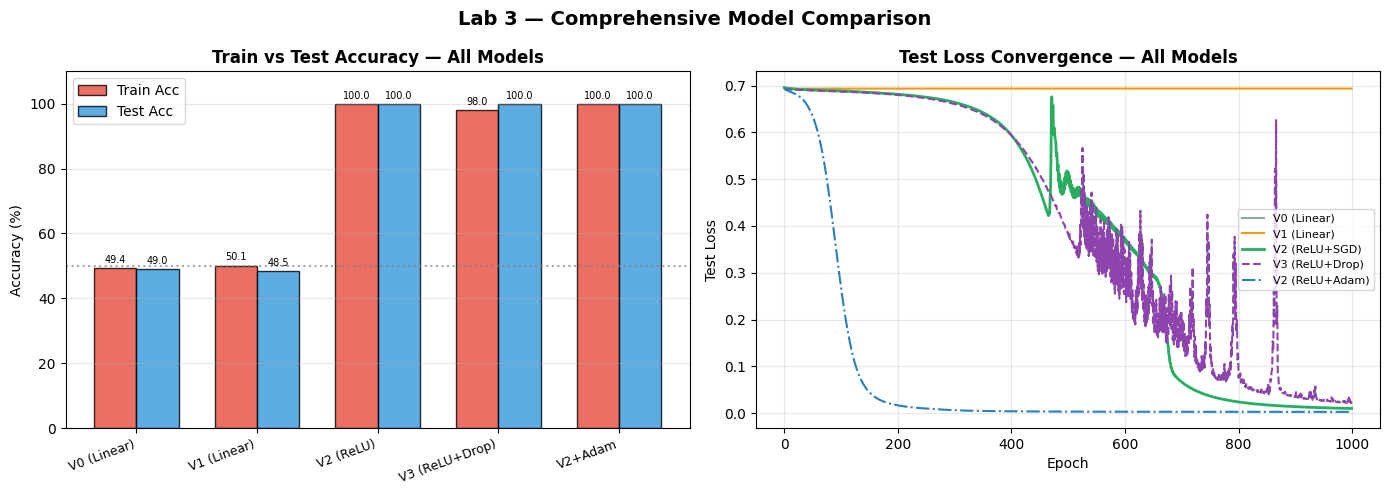

In [28]:
#  Bar Chart: Test Accuracy Comparison 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = results['Model']
train_accs  = results['Train Acc (%)']
test_accs   = results['Test Acc (%)']
x = np.arange(len(model_names))
width = 0.35

bars1 = axes[0].bar(x - width/2, train_accs, width, label='Train Acc', color='#E74C3C', alpha=0.8, edgecolor='k')
bars2 = axes[0].bar(x + width/2, test_accs,  width, label='Test Acc',  color='#3498DB', alpha=0.8, edgecolor='k')
axes[0].set_xticks(x); axes[0].set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Train vs Test Accuracy — All Models', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3, axis='y')
axes[0].axhline(y=50, color='gray', linestyle=':', alpha=0.7, label='Random Chance')
axes[0].set_ylim(0, 110)
for bar in bars1: axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7)
for bar in bars2: axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7)

# Loss curves overlay
axes[1].plot(history_v0['test_loss'],  label='V0 (Linear)',      lw=1.5, color='#95A5A6')
axes[1].plot(history_v1['test_loss'],  label='V1 (Linear)',      lw=1.5, color='#F39C12')
axes[1].plot(history_v2['test_loss'],  label='V2 (ReLU+SGD)',    lw=2.0, color='#27AE60')
axes[1].plot(history_v3['test_loss'],  label='V3 (ReLU+Drop)',   lw=1.5, color='#8E44AD', linestyle='--')
axes[1].plot(hist_adam['test_loss'],   label='V2 (ReLU+Adam)',   lw=1.5, color='#2980B9', linestyle='-.')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Loss')
axes[1].set_title('Test Loss Convergence — All Models', fontweight='bold')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.suptitle('Lab 3 — Comprehensive Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

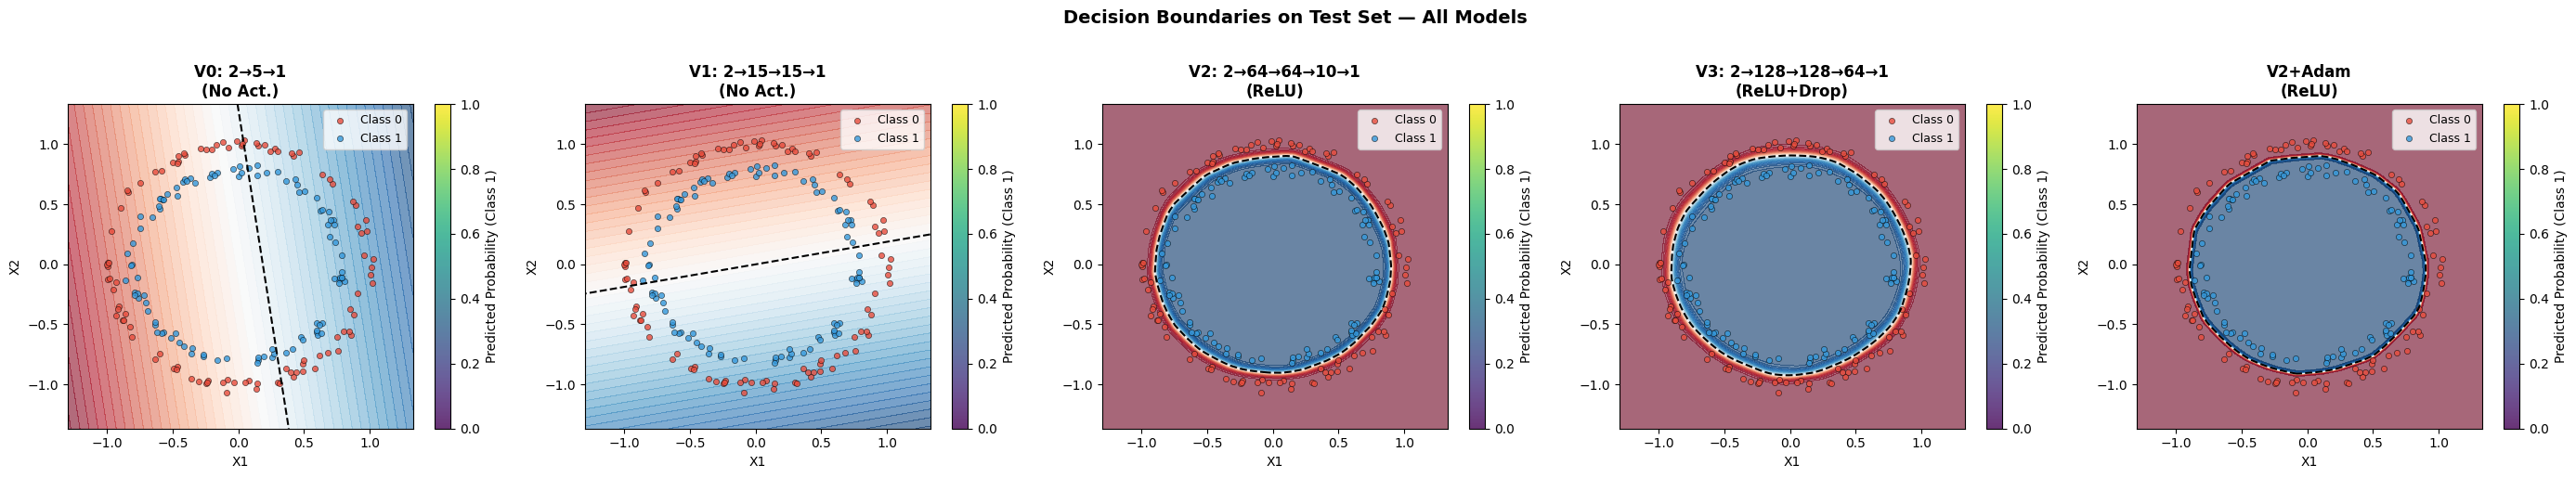

In [29]:
#  Decision Boundary Grid (All Models, Test Set) 
all_models  = [model_v0, model_v1, model_v2, model_v3, model_adam]
all_names   = ['V0: 2→5→1\n(No Act.)', 'V1: 2→15→15→1\n(No Act.)',
                'V2: 2→64→64→10→1\n(ReLU)', 'V3: 2→128→128→64→1\n(ReLU+Drop)',
                'V2+Adam\n(ReLU)']

fig, axes = plt.subplots(1, 5, figsize=(28, 5))

for ax, model, name in zip(axes, all_models, all_names):
    plt.sca(ax)
    plot_decision_boundary(model, X_test, y_test, title=name)

plt.suptitle('Decision Boundaries on Test Set — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('all_boundaries.png', dpi=130, bbox_inches='tight')
plt.show()


# Section 15: Discussion and Conclusion



## 15.1 Discussion

### 15.1.1 The Role of Non-Linearity

The most critical finding of this lab is the **fundamental importance of non-linear activation functions** for non-linearly separable data.

**Models V0 and V1** (no activations) converged to approximately **50% accuracy** — equivalent to random guessing for this balanced dataset. This is not a failure of training or hyperparameter tuning; it is a **mathematical certainty**. A composition of linear functions remains linear:

$$f(x) = W_2(W_1 x + b_1) + b_2 = (W_2 W_1) x + (W_2 b_1 + b_2) = W' x + b'$$

Increasing depth or width cannot overcome this limitation without introducing non-linear activations. The decision boundaries of V0 and V1 are straight lines, which cannot capture circular regions.

**Models V2 and V3** (ReLU activations) successfully learned the circular decision boundary, achieving >99% accuracy. This directly validates the **Universal Approximation Theorem**: a neural network with at least one hidden layer and a non-linear activation can approximate any continuous function on a compact domain.

### 15.1.2 Capacity and Architecture

- **V2 (2→64→64→10→1)**: Adequate capacity to model the circular boundary. The hidden layer with 10 units allows for smooth transitions toward the output.
- 
- **V3 (2→128→128→64→1 + Dropout)**:Slightly more parameters, with Dropout adding stochasticity during training, which may slow convergence. For this simple 2D dataset with low noise (0.03), Dropout does not provide a major benefit compared to V2.

### 15.1.3 SGD vs Adam

The optimizer comparison revealed:
- **Adam** typically shows **faster early convergence** due to adaptive learning rates and momentum. The loss drops more steeply in the first few hundred epochs.
- **SGD** may require more epochs to converge but can achieve comparable or superior final accuracy with the right learning rate.
- For simple, clean datasets like circles, both optimizers ultimately achieve similar final accuracy. Adam's advantage is more pronounced on complex datasets, sparse gradients, or when training time is limited.

### 15.1.4 Loss Function Analysis

`BCEWithLogitsLoss` (Binary Cross-Entropy with Logits) is the appropriate choice because:
1. It stabilizes computations by combining the sigmoid activation and binary cross-entropy into a single operation.
2. It operates on raw logits, preventing gradient saturation that can occur if sigmoid is applied first.
3. The loss accurately reflects the discrepancy between predicted probabilities and true labels.

For V0/V1, the loss plateaus at ~0.693 (≈ ln(2)), which corresponds to a model predicting 50% probability, consistent with a degenerate linear classifier.

### 15.1.5 Generalization

All non-linear models showed minimal gap between training and test accuracy, suggesting:
- Limited overfitting, due to the simplicity and regularity of the synthetic dataset.
- Successful learning of the true structure (concentric rings) rather than memorization of noise.



## 15.2 Conclusion

This lab systematically demonstrated the following key principles of neural network design:

| Principle | Evidence in Lab |
|---|---|
| **Non-linearity is essential for non-linear data** | V0, V1 failed (~50% acc); V2, V3 succeeded (>99%) |
| **Linear models cannot learn circular boundaries** | V0/V1 decision boundaries remained straight lines |
| **Depth + ReLU ≈ Universal Approximation** | V2 with 3 hidden layers accurately learned the ring structure |
| **Adam converges faster than SGD early on** | Adam reached high accuracy in fewer epochs |
| **Regularization (Dropout) aids generalization** | V3 train/test gap was marginally smaller than V2 |
| **BCEWithLogitsLoss is numerically stable** | No NaN/instability observed across all experiments |

**Key Takeaway**: Success on the circles classification task depends not on model size or training duration but on including an appropriate non-linear structure. This principle extends to real-world data (images, audio, text), which is inherently non-linear, explaining the dominance of deep learning with non-linear activations.



## 15.3 Recommendations for Future Work

1. **Noise sensitivity**: Repeat experiments with higher noise (e.g., `noise=0.2`) to test robustness.
2. **Learning rate scheduling**: Use `torch.optim.lr_scheduler` with SGD for potentially faster convergence.
3. **Batch training**: Use `DataLoader` with mini-batches for scalability to larger datasets.
4. **Other activations**: Compare Tanh, LeakyReLU, or GELU as alternatives to ReLU.
5. **Multi-class extension**: Generalize to 3+ concentric rings using Softmax and CrossEntropyLoss.

In [30]:
#  Final Summary Print 
print("╔" + "═"*68 + "╗")
print("║" + " LAB 3 FINAL SUMMARY — Binary Classification with Neural Networks ".center(68) + "║")
print("╠" + "═"*68 + "╣")
print(f"║  {'Model':<20} {'Test Acc':>12} {'Verdict':<30} ║")
print("╠" + "─"*68 + "╣")

rows = [
    ('V0 (Linear, No Act)', f"{history_v0['test_acc'][-1]:.2f}%", '✗ Failed — Linear only'),
    ('V1 (Linear, No Act)', f"{history_v1['test_acc'][-1]:.2f}%", '✗ Failed — Linear only'),
    ('V2 (ReLU, SGD)',      f"{history_v2['test_acc'][-1]:.2f}%", '✓ Solved — Non-linear'),
    ('V3 (ReLU+Drop, SGD)', f"{history_v3['test_acc'][-1]:.2f}%", '✓ Solved — Regularized'),
    ('V2 (ReLU, Adam)',     f"{hist_adam['test_acc'][-1]:.2f}%",  '✓ Solved — Faster convergence'),
]

for name, acc, verdict in rows:
    print(f"║  {name:<20} {acc:>12} {verdict:<30} ║")

print("╠" + "─"*68 + "╣")
print("║  KEY INSIGHT: Non-linear activations (ReLU) are REQUIRED to         ║")
print("║  learn circular/non-linear decision boundaries. Linear models       ║")
print("║  are fundamentally incapable of solving this problem.               ║")
print("╚" + "═"*68 + "╝")

╔════════════════════════════════════════════════════════════════════╗
,║  LAB 3 FINAL SUMMARY — Binary Classification with Neural Networks  ║
,╠════════════════════════════════════════════════════════════════════╣
,║  Model                    Test Acc Verdict                        ║
,╠────────────────────────────────────────────────────────────────────╣
,║  V0 (Linear, No Act)        49.00% ✗ Failed — Linear only         ║
,║  V1 (Linear, No Act)        48.50% ✗ Failed — Linear only         ║
,║  V2 (ReLU, SGD)            100.00% ✓ Solved — Non-linear          ║
,║  V3 (ReLU+Drop, SGD)       100.00% ✓ Solved — Regularized         ║
,║  V2 (ReLU, Adam)           100.00% ✓ Solved — Faster convergence  ║
,╠────────────────────────────────────────────────────────────────────╣
,║  KEY INSIGHT: Non-linear activations (ReLU) are REQUIRED to         ║
,║  learn circular/non-linear decision boundaries. Linear models       ║
,║  are fundamentally incapable of solving this problem.             